In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
from collections import Counter

In [2]:
# Download required NLTK datasets
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\marut\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\marut\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\marut\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\marut\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [3]:
# Load dataset
data = pd.read_csv("Mental-Health-Twitter.csv")


In [4]:
data.head()

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1


In [5]:
df=data[['post_text','label']]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   post_text  20000 non-null  object
 1   label      20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB


In [7]:
# Check for null values
df.dropna(subset=['post_text', 'label'], inplace=True)

C:\Users\marut\AppData\Local\Temp\ipykernel_15828\1732361036.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['post_text', 'label'], inplace=True)


In [8]:
# Text Preprocessing: 
def preprocess_text(text):
    text = text.lower()  # Converting to lowercase
    text = re.sub(r"http\S+|@\S+|[^A-Za-z\s]", '', text)  # Removing links from tweets
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Removing special characters & numbers
    words = word_tokenize(text)  # apply tokenization ie splits text into individual words
    words = [word for word in words if word not in stopwords.words('english')]  # Removing stopwords
    
    # Stemming
    stemmer = PorterStemmer()
    words = [stemmer.stem(word) for word in words]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return ' '.join(words)

In [9]:
# Apply preprocessing
df['cleaned_text'] = df['post_text'].apply(preprocess_text)

C:\Users\marut\AppData\Local\Temp\ipykernel_15828\3759637655.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cleaned_text'] = df['post_text'].apply(preprocess_text)


EDA

In [10]:
# Ensure 'cleaned_text' is tokenized
df['tokenized_text'] = df['cleaned_text'].apply(word_tokenize)

# Flatten all words into a list for frequency analysis
all_words = [word for text in df['tokenized_text'] for word in text]

C:\Users\marut\AppData\Local\Temp\ipykernel_15828\1029057112.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokenized_text'] = df['cleaned_text'].apply(word_tokenize)


C:\Users\marut\AppData\Local\Temp\ipykernel_15828\1828769997.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=common_words_df['Word'], y=common_words_df['Frequency'], palette="mako")


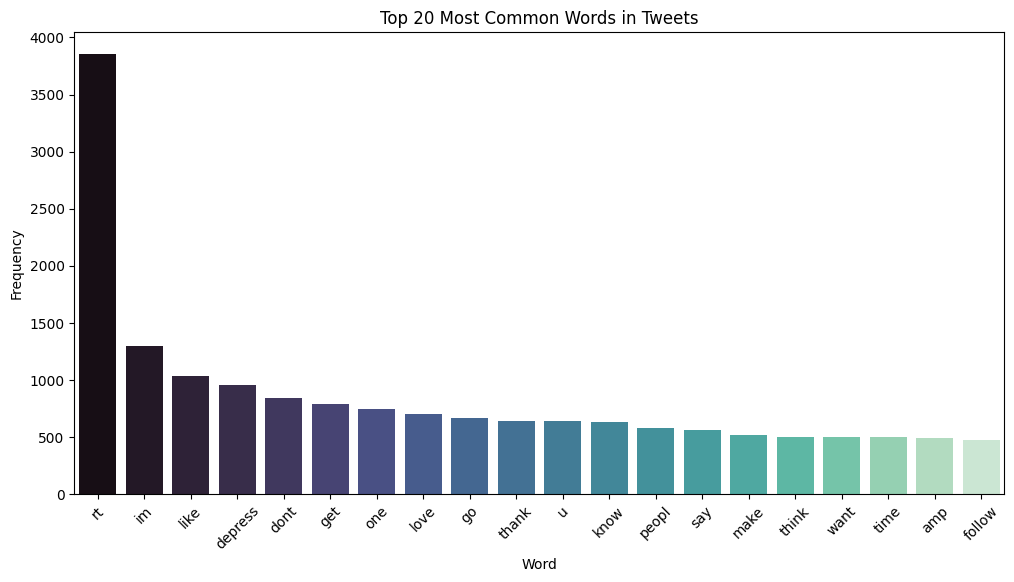

In [11]:
# Most Common Words plot
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)  # Top 20 words
common_words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 6))
sns.barplot(x=common_words_df['Word'], y=common_words_df['Frequency'], palette="mako")
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Words in Tweets")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.show()

C:\Users\marut\AppData\Local\Temp\ipykernel_15828\3431930424.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tweet_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))


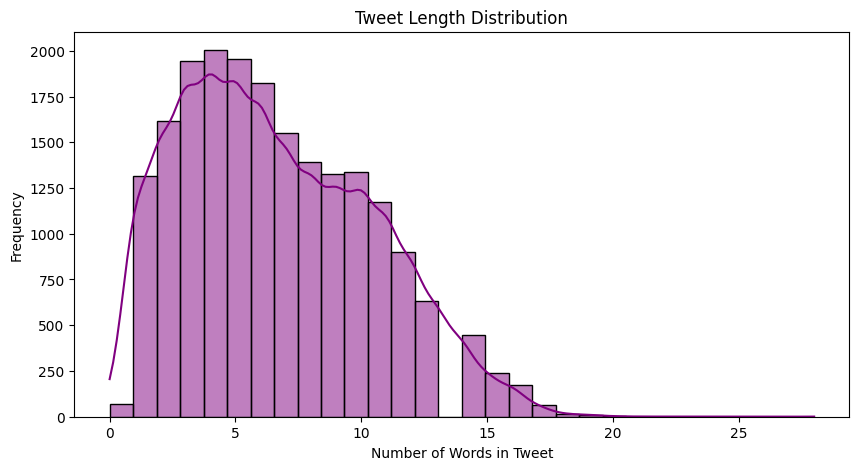

In [12]:
# Tweet Length Distribution
df['tweet_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 5))
sns.histplot(df['tweet_length'], bins=30, kde=True, color="purple")
plt.title("Tweet Length Distribution")
plt.xlabel("Number of Words in Tweet")
plt.ylabel("Frequency")
plt.show()

In [13]:
# Part-of-Speech (POS) Tagging
#Assigns a grammatical label (noun, verb, adjective, etc.) to each word
#It helps in understanding sentence structure and context.
def pos_tagging(text):
    words = word_tokenize(text)
    return pos_tag(words)

df['pos_tags'] = df['cleaned_text'].apply(pos_tagging)

C:\Users\marut\AppData\Local\Temp\ipykernel_15828\1145526784.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pos_tags'] = df['cleaned_text'].apply(pos_tagging)


In [14]:
# Feature Extraction (TF-IDF and Bag-of-Words)
#Converts text into a numerical representation by measuring word importance in a document.

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['cleaned_text']).toarray()

# it creates a word frequency representation of text
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['cleaned_text']).toarray()

In [15]:
# Topic Modeling using LSI
# Identifies Latent topics in text using SVD.
lsi = TruncatedSVD(n_components=5)
topic_matrix = lsi.fit_transform(X_tfidf)
df['topic'] = np.argmax(topic_matrix, axis=1)


C:\Users\marut\AppData\Local\Temp\ipykernel_15828\310776305.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['topic'] = np.argmax(topic_matrix, axis=1)


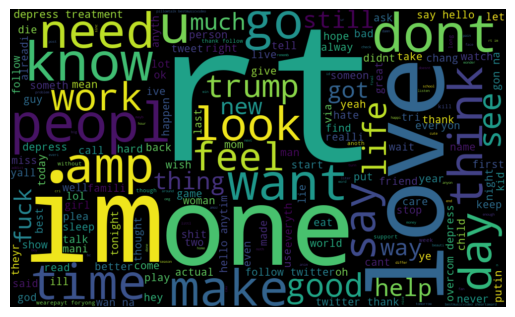

In [16]:
# Word Cloud Visualization
#Create a plot of the most frequently used words.
wordcloud = WordCloud(width=1000, height=600).generate(' '.join(df['cleaned_text']))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [17]:
# Model Training & Prediction
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['label'], test_size=0.2, random_state=42)

In [18]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test,y_pred))

Accuracy: 0.7525
              precision    recall  f1-score   support

           0       0.74      0.77      0.75      1981
           1       0.76      0.74      0.75      2019

    accuracy                           0.75      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.75      0.75      0.75      4000



In [19]:
#Sentiment Analsis
# Install the Vader lexicon 
import nltk
nltk.download('vader_lexicon')

# Import VADER SentimentIntensityAnalyzer
from nltk.sentiment import SentimentIntensityAnalyzer

# Initialize Sentiment Analyzer
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\marut\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [20]:
# Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()
df['sentiment'] = df['cleaned_text'].apply(lambda text: analyzer.polarity_scores(text)['compound'])

C:\Users\marut\AppData\Local\Temp\ipykernel_15828\2256099594.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = df['cleaned_text'].apply(lambda text: analyzer.polarity_scores(text)['compound'])


In [21]:
# Sentiment Analysis
df['sentiment_score'] = df['post_text'].apply(lambda text: analyzer.polarity_scores(text)['compound'])

# Categorize into Positive, Negative, Neutral
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)

C:\Users\marut\AppData\Local\Temp\ipykernel_15828\3264203683.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment_score'] = df['post_text'].apply(lambda text: analyzer.polarity_scores(text)['compound'])
C:\Users\marut\AppData\Local\Temp\ipykernel_15828\3264203683.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)


In [22]:
# Display first few results
print(df[['post_text', 'sentiment', 'sentiment_score']].head(10))

                                           post_text sentiment  \
0  It's just over 2 years since I was diagnosed w...   Neutral   
1  It's Sunday, I need a break, so I'm planning t...   Neutral   
2  Awake but tired. I need to sleep but my brain ...  Negative   
3  RT @SewHQ: #Retro bears make perfect gifts and...  Positive   
4  It’s hard to say whether packing lists are mak...  Positive   
5  Making packing lists is my new hobby... #movin...   Neutral   
6  At what point does keeping stuff for nostalgic...   Neutral   
7  Currently in the finding-boxes-of-random-shit ...   Neutral   
8  Can't be bothered to cook, take away on the wa...  Positive   
9  RT @itventsnews: ITV releases promo video for ...   Neutral   

   sentiment_score  
0           0.0000  
1           0.0000  
2          -0.5927  
3           0.8550  
4           0.3400  
5           0.0000  
6           0.0000  
7           0.0000  
8           0.2411  
9           0.0000  


In [23]:
print(df['sentiment'].value_counts())

sentiment
Neutral     7385
Positive    7279
Negative    5336
Name: count, dtype: int64


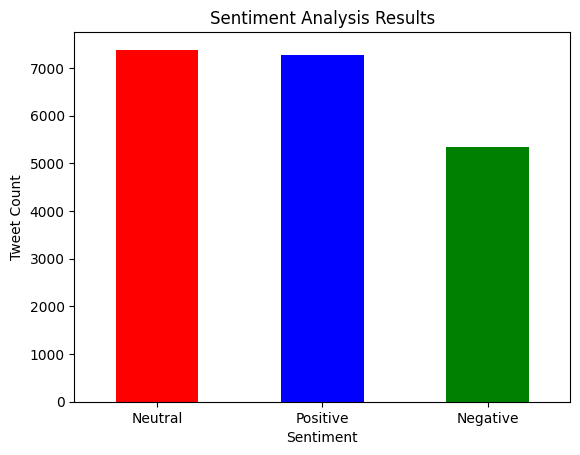

In [24]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar', color=['red', 'blue', 'green'])
plt.title("Sentiment Analysis Results")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")
plt.xticks(rotation=0)
plt.show()

In [25]:
df

,post_text,label,cleaned_text,tokenized_text,tweet_length,pos_tags,topic,sentiment,sentiment_score
0,It's just over 2 years since I was diagnosed w...,1,year sinc diagnos anxieti depress today im tak...,"[year, sinc, diagnos, anxieti, depress, today,...",14,"[(year, NN), (sinc, NN), (diagnos, VBP), (anxi...",2,Neutral,0.0000
1,"It's Sunday, I need a break, so I'm planning t...",1,sunday need break im plan spend littl time pos...,"[sunday, need, break, im, plan, spend, littl, ...",9,"[(sunday, RB), (need, MD), (break, VB), (im, J...",0,Neutral,0.0000
2,Awake but tired. I need to sleep but my brain ...,1,awak tire need sleep brain idea,"[awak, tire, need, sleep, brain, idea]",6,"[(awak, NN), (tire, NN), (need, VBP), (sleep, ...",0,Negative,-0.5927
3,RT @SewHQ: #Retro bears make perfect gifts and...,1,rt retro bear make perfect gift great beginn g...,"[rt, retro, bear, make, perfect, gift, great, ...",14,"[(rt, NN), (retro, NN), (bear, VBP), (make, VB...",0,Positive,0.8550
4,It’s hard to say whether packing lists are mak...,1,hard say whether pack list make life easier re...,"[hard, say, whether, pack, list, make, life, e...",14,"[(hard, JJ), (say, VBP), (whether, IN), (pack,...",0,Positive,0.3400
...,...,...,...,...,...,...,...,...,...
19995,A day without sunshine is like night.,0,day without sunshin like night,"[day, without, sunshin, like, night]",5,"[(day, NN), (without, IN), (sunshin, NN), (lik...",0,Negative,-0.5773
19996,"Boren's Laws: (1) When in charge, ponder. (2) ...",0,boren law charg ponder troubl deleg doubt mumbl,"[boren, law, charg, ponder, troubl, deleg, dou...",8,"[(boren, NN), (law, NN), (charg, NN), (ponder,...",0,Negative,-0.6369
19997,The flow chart is a most thoroughly oversold p...,0,flow chart thoroughli oversold piec program do...,"[flow, chart, thoroughli, oversold, piec, prog...",13,"[(flow, JJ), (chart, NN), (thoroughli, NN), (o...",0,Neutral,0.0000
19998,"Ships are safe in harbor, but they were never ...",0,ship safe harbor never meant stay,"[ship, safe, harbor, never, meant, stay]",6,"[(ship, NN), (safe, JJ), (harbor, NN), (never,...",0,Positive,0.2382


In [26]:
import joblib
joblib.dump(model, 'mental_health_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']